## PRISM Repurposing Analysis — BAF Expression vs Drug Sensitivity
### Author: Eleni Aretaki
### Date: 2026-03-31 (last edited)

### Purpose:
Test whether LOW vs HIGH BAF expression (CCLE) affects PRISM drug repurposing sensitivity
using Mann–Whitney U test in both primary and secondary screens.

Paper: https://doi.org/10.1038/s43018-019-0018-6

In [ ]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.stats.multitest as smt
from scipy import stats
import time

In [ ]:
# -------------------------------
# File paths & constants
# -------------------------------
baf_exp = pd.read_csv('../baf_expression.csv')
mfi_values = pd.read_csv('../mfi_values.csv')
dose_response = pd.read_csv('../dose_response_parameters.csv')
drugs = pd.read_csv('../drugs_annotation.csv')

FDR_THRESHOLD = 0.01
LOW_PERCENTILE = 0.20
HIGH_PERCENTILE = 0.80

# Keep main BAF genes only
subunits_to_remove = [
    'ACTL6B','BICRA','SMARCE1','ACTB','BCL7C','BCL11A','BCL11B',
    'SMARCC2','BCL7B','ACTL6A','SS18','SMARCD3','SMARCD2',
    'BCL7A','BICRAL','SS18L1','SMARCA2','SMARCB1','DPF1', 'DPF2'
]

pattern = '|'.join(subunits_to_remove)

mask = baf_exp.apply(
    lambda row: row.str.contains(pattern, case=False).any(),
    axis=1
)

baf_exp = baf_exp[~mask]

In [ ]:
# -------------------------------
# Function for expression categorization (20/80th percentile)
# -------------------------------
def categorize_expression_levels(df):

    grouped = df.groupby('gene_symbol')['expression_level']

    percentiles = grouped.quantile(
        [LOW_PERCENTILE, HIGH_PERCENTILE]
    ).unstack()

    percentiles.columns = ['low_cut', 'high_cut']

    df = df.merge(percentiles, on='gene_symbol')

    df['expression_category'] = np.where(
        df['expression_level'] <= df['low_cut'], 'low',
        np.where(
            df['expression_level'] >= df['high_cut'],
            'high',
            'mid'
        )
    )

    df = df[df['expression_category'].isin(['low','high'])]

    return df.drop(columns=['low_cut','high_cut'])


baf_exp_perc = categorize_expression_levels(baf_exp)

In [ ]:
# -------------------------------
# Mann-Whitney function
# -------------------------------
def mann_whitney_test(group, value_col):

    low = group[group['expression_category']=='low'][value_col]
    high = group[group['expression_category']=='high'][value_col]

    if low.empty or high.empty:
        return pd.Series({
            'u_statistic': np.nan,
            'p_value': np.nan,
            'low_mean': low.mean(),
            'high_mean': high.mean()
        })

    u, p = stats.mannwhitneyu(low, high)

    return pd.Series({
        'u_statistic': u,
        'p_value': p,
        'low_mean': low.mean(),
        'high_mean': high.mean()
    })

In [ ]:
# -------------------------------
# PRIMARY PRISM - MFI values
# -------------------------------
merged_primary = baf_exp_perc.merge(
    mfi_values,
    on='cell_line'
)

# Run tests
results_primary = (
    merged_primary
    .groupby(['gene_symbol','drug_id'])
    .apply(lambda g: mann_whitney_test(g,'mfi_value'))
    .reset_index()
)

In [ ]:
# -------------------------------
# SECONDARY PRISM - AUC of dose-response curves
# -------------------------------
dose_response = dose_response[dose_response['r2'] > 0]

merged_secondary = baf_exp_perc.merge(
    dose_response,
    on='cell_line'
)

# Run tests
results_secondary = (
    merged_secondary
    .groupby(['gene_symbol','drug_id'])
    .apply(lambda g: mann_whitney_test(g,'auc'))
    .reset_index()
)

In [ ]:
# ===============================
# MERGE PRIMARY + SECONDARY
# ===============================
utest = pd.merge(results_primary, results_secondary, on=['gene_symbol','drug_id'], suffixes=('_primary','_secondary'))

# Keep only gene × drug pairs that exist in both screens
utest = utest.dropna(subset=['p_value_primary','p_value_secondary'])

# ===============================
# FDR ADJUSTMENT (AFTER MERGE)
# ===============================
_, padj_primary, _, _ = smt.multipletests(utest['p_value_primary'], method='fdr_bh')
_, padj_secondary, _, _ = smt.multipletests(utest['p_value_secondary'], method='fdr_bh')
utest['padj_primary_fdr'] = padj_primary
utest['padj_secondary_fdr'] = padj_secondary

# ===============================
# CALCULATE MEAN DIFFERENCE
# ===============================
utest['mean_difference_primary'] = utest['high_mean_primary'] - utest['low_mean_primary']
utest['mean_difference_secondary'] = utest['high_mean_secondary'] - utest['low_mean_secondary']

# ===============================
# FILTER SIGNIFICANT RESULTS
# ===============================
significant_utest = utest[(utest['padj_primary_fdr']<0.01) & (utest['padj_secondary_fdr']<0.01)]

# Merge drug names and MOA
significant_utest = significant_utest.merge(drugs[['drug_id','drug_name','MOA']], on='drug_id')

# Significant in BOTH screens
utest['significant'] = (
    (utest['padj_primary_fdr'] < FDR_THRESHOLD) &
    (utest['padj_secondary_fdr'] < FDR_THRESHOLD)
)

In [ ]:
# -------------------------------
# Plotting preparation
# -------------------------------

# ===============================
# ADD DRUG ANNOTATIONS
# ===============================

utest = drugs.merge(
    utest,
    on='drug_id'
)

# Keep relative to the analysis BAF genes only
baf_genes = [
    "ARID1A","ARID1B","ARID2",
    "BRD7","PHF10","PBRM1",
    "BRD9","SMARCD1","SMARCC1","SMARCA4"
]

utest = utest[
    utest['gene_symbol'].isin(baf_genes)
]

# ===============================
# KEEP DRUGS WITH AT LEAST ONE HIT 
# ===============================

# Keep drugs with at least one significant hit in one of the BAF genes
keep = (
    utest.groupby('drug_name')['significant']
    .any()
)

keep = keep[keep].index

filtered = utest[
    utest['drug_name'].isin(keep)
]

# ===============================
# SORT BY MOA THEN DRUG
# ===============================
filtered = filtered.sort_values(
    by=['MOA','drug_name']
)

# Gene order
gene_order = [
    "ARID1A","ARID1B","ARID2",
    "BRD7","PHF10","PBRM1",
    "BRD9","SMARCD1","SMARCC1","SMARCA4"
]

# ===============================
# PIVOT FOR HEATMAP
# ===============================
heatmap_df = filtered.pivot(
    index='drug_name',
    columns='gene_symbol',
    values='mean_difference_primary'
)[gene_order]

signif_df = filtered.pivot(
    index='drug_name',
    columns='gene_symbol',
    values='significant'
)[gene_order]

heatmap_df = heatmap_df.loc[
    filtered['drug_name'].unique()
]

signif_df = signif_df.loc[
    filtered['drug_name'].unique()
]

# ===============================
# INVERT (to match Olivieri direction)
# ===============================
heatmap_df = heatmap_df * -1

# ===============================
# RENAME MOA
# ===============================
rename_moa = {
    'BCR-ABL KINASE INHIBITOR, EPHRIN INHIBITOR, KIT INHIBITOR, PDGFR TYROSINE KINASE RECEPTOR INHIBITOR, SRC INHIBITOR, TYROSINE KINASE INHIBITOR': 'BCR-ABL kinase inhibitor',
    'EGFR INHIBITOR, RET TYROSINE KINASE INHIBITOR, VEGFR INHIBITOR': 'EGFR/VEGFR inhibitor',
    'EGFR INHIBITOR, VEGFR INHIBITOR': 'EGFR/VEGFR inhibitor',
    'EGFR INHIBITOR': 'EGFR inhibitor',
    'PARP INHIBITOR': 'PARP inhibitor',
    'MEK INHIBITOR': 'MEK inhibitor',
    'HDAC INHIBITOR': 'HDAC inhibitor',
    'SRC INHIBITOR': 'SRC inhibitor',
    'TOPOISOMERASE INHIBITOR': 'Topoisomerase inhibitor',
    'CHOLERETIC AGENT': 'Choleretic agent',
    "BRUTON'S TYROSINE KINASE (BTK) INHIBITOR": 'BTK inhibitor',
    'EGFR INHIBITOR, RET TYROSINE KINASE INHIBITOR, VEGFR INHIBITOR': 'EGFR/VEGFR inhibitor',
    'DNA ALKYLATING AGENT, DNA INHIBITOR': 'DNA alkylating agent',
    'ABL KINASE INHIBITOR, SRC INHIBITOR, VEGFR INHIBITOR': 'ABL/SRC/VEGFR inhibitor'
}

filtered['MOA'] = filtered['MOA'].replace(rename_moa)

# ===============================
# CREATE MOA COLOR MAP
# ===============================
# Color palette
base_colors = list(plt.cm.tab20b.colors)
extra_colors = list(plt.cm.tab20c.colors[:5])
extended_colors = base_colors + extra_colors

# Fixed PARP color
parp_color = extended_colors[11]

# All MOAs
moas = filtered['MOA'].unique()

# Assign PARP first
moa_colors = {'PARP inhibitor': parp_color}

# Assign remaining MOAs
other_moas = [m for m in moas if m != 'PARP inhibitor']
other_colors = [c for c in extended_colors if c != parp_color]

for moa, color in zip(other_moas, other_colors):
    moa_colors[moa] = color

# Drug → MOA map
drug_moa = (
    filtered[['drug_name','MOA']]
    .drop_duplicates()
    .set_index('drug_name')['MOA']
    .to_dict()
)

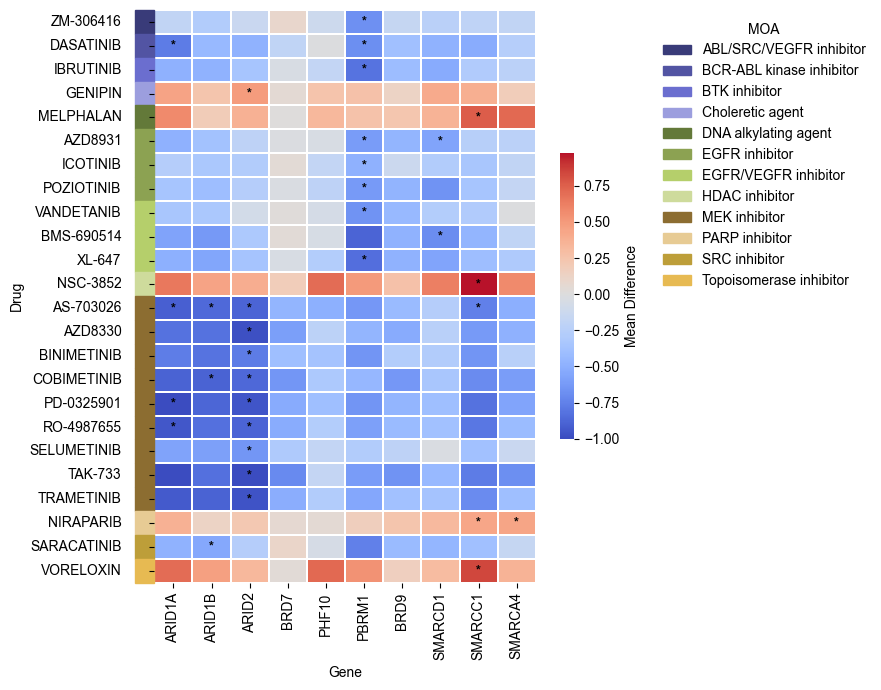

In [113]:
# -------------------------------
# Plotting 
# -------------------------------
plt.rcParams['font.family'] = 'Arial'

# ===============================
# PLOT HEATMAP
# ===============================
fig, ax = plt.subplots(figsize=(9,7))

sns.heatmap(
    heatmap_df,
    cmap='coolwarm',
    center=0,
    linewidths=0.2,
    cbar_kws={'label':'Mean Difference','shrink':0.5},
    ax=ax
)

# ===============================
# ADD SIGNIFICANCE STARS
# ===============================
for y, drug in enumerate(heatmap_df.index):
    for x, gene in enumerate(heatmap_df.columns):

        if signif_df.loc[drug,gene]:
            ax.text(
                x+0.5,
                y+0.5,
                '*',
                ha='center',
                va='center',
                color='black',
                fontsize=9,
                fontweight='bold'
            )

# ===============================
# ADD MOA COLOR BAR
# ===============================
for y, drug in enumerate(heatmap_df.index):

    ax.add_patch(
        mpatches.Rectangle(
            (0,y),
            -0.05,
            1,
            color=moa_colors[drug_moa[drug]],
            transform=ax.get_yaxis_transform(),
            clip_on=False
        )
    )

ax.tick_params(axis='y', pad=20)

# ===============================
# MOA LEGEND
# ===============================
present_moas = [drug_moa[d] for d in heatmap_df.index]
present_moas = list(dict.fromkeys(present_moas))

handles = [
    mpatches.Patch(color=moa_colors[m], label=m)
    for m in present_moas
]

ax.legend(
    handles=handles,
    title='MOA',
    bbox_to_anchor=(1.3,1),
    loc='upper left',
    frameon=False
)

# ===============================
# LABELS 
# ===============================
ax.set_xlabel('Gene')
ax.set_ylabel('Drug')

plt.tight_layout()

fig.savefig(
    'prism_baf_expression_heatmap.pdf',
    dpi=600
)

plt.show()
plt.close()